# Intermediate Quantum Algorithms
## VQE · QAOA · QITE · Quantum Krylov

This notebook covers the four intermediate algorithms from the NISQ research frontier. Unlike the simple algorithms (Deutsch-Jozsa, Grover), these:

- Require **more qubits** and deeper circuits
- Are **hybrid** — quantum and classical computers work together
- Have **real but uncertain** quantum advantage — not yet proven at scale
- Are the **active research frontier** of NISQ computing today

For each algorithm we cover:
1. What problem it solves
2. How it works (with simulation on small systems)
3. Classical comparison
4. Hardware requirements — which machines can run it today and when larger instances become feasible
5. Honest evaluation

| Algorithm | Min qubits (useful) | NISQ ready | Key challenge | Best for |
|-----------|--------------------|-----------|--------------|---------|
| VQE | 4–10 | Yes | Barren plateaus | Quantum chemistry, ground states |
| QAOA | 4–20 | Yes | Shallow circuits limit quality | Combinatorial optimisation |
| QITE | 4–12 | Partial | Circuit depth grows with time | Ground states without ansatz |
| Quantum Krylov | 4–16 | Partial | Overlap estimation cost | Excited states, spectroscopy |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp, Statevector

sim = AerSimulator(method='statevector')

CLASSICAL_COLOR = '#E74C3C'
QUANTUM_COLOR   = '#2E75B6'
ACCENT_COLOR    = '#1ABC9C'
WARN_COLOR      = '#E67E22'
PURPLE_COLOR    = '#6C3483'

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

def make_ising_H(n, J=1.0, h=0.5):
    """1D transverse-field Ising Hamiltonian: H = J*sum(ZiZi+1) + h*sum(Xi)"""
    terms = []
    for i in range(n-1):
        pauli = 'I'*(n-2-i) + 'ZZ' + 'I'*i
        terms.append((pauli, J))
    for i in range(n):
        pauli = 'I'*(n-1-i) + 'X' + 'I'*i
        terms.append((pauli, h))
    return SparsePauliOp.from_list(terms)

def exact_ground_state(H_op):
    """Exact ground state energy and vector via full diagonalisation."""
    Hm = H_op.to_matrix()
    evals, evecs = np.linalg.eigh(Hm)
    return evals[0], evecs[:, 0], evals

print('Setup complete.')
print('Libraries: Qiskit, Qiskit-Aer, NumPy, SciPy, Matplotlib')

Setup complete.
Libraries: Qiskit, Qiskit-Aer, NumPy, SciPy, Matplotlib


---
## Hardware Context: What Can Run These Algorithms?

Before diving in, it is important to understand the hardware landscape. Intermediate algorithms need more qubits *and* more reliable qubits than simple algorithms.

The key metric is not just qubit count — it is **quantum volume** or equivalently the product of reliable qubit count and circuit depth that fits within coherence time.

| System | Qubits | Coherence | 2Q gate fidelity | Can run today | Target horizon |
|--------|--------|-----------|-----------------|---------------|----------------|
| AaltoQ20 (IQM) | 20 | ~1 ms | ~99% | VQE (2–4 qubits), QAOA (4–6 qubits) | Research/education |
| IQM Radiance | 54 | ~1 ms | ~99.5% | VQE (6–10 qubits), QAOA (10–20 qubits) | Now |
| IBM Eagle/Heron | 127–133 | ~100 µs | ~99.5% | VQE (10–20 qubits), QAOA (20–50 qubits) | Now |
| Google Willow | 105 | ~100 µs | ~99.7% | VQE (10–20 qubits) | Now |
| IQM 300-qubit (planned) | 300 | ~1 ms | >99.5% | Larger VQE/QAOA | ~2027 |
| Early fault-tolerant | ~1000 logical | Hours | >99.99% | QITE, Krylov at scale | ~2030 |

**The simulations in this notebook use 2–8 qubits** — small enough for exact classical simulation, large enough to demonstrate the algorithmic principles. The concepts scale directly to larger hardware.

---
# 1. VQE — Variational Quantum Eigensolver

### Problem
Find the ground state energy $E_0$ of a quantum Hamiltonian $H$:
$$E_0 = \min_{|\psi\rangle} \langle \psi | H | \psi \rangle$$

This is fundamental to quantum chemistry (molecular energies), materials science (band gaps), and condensed matter physics (phase transitions).

### The variational principle
For any trial state $|\psi(\theta)\rangle$, the expectation value is always an upper bound:
$$\langle \psi(\theta) | H | \psi(\theta) \rangle \geq E_0$$

So: minimise $\langle H \rangle$ over parameters $\theta$ → converges to $E_0$.

### The hybrid loop
```
Quantum:   prepare |ψ(θ)⟩ → measure ⟨H⟩
Classical: optimise θ to lower ⟨H⟩
Repeat until convergence
```

4-qubit transverse Ising chain
Exact ground state energy: -3.427034
First excited state:       -3.332247
Gap:                       0.094788

VQE result (best of 8 trials): -3.381502
Exact ground state:            -3.427034
Error:                         0.045532
Chemical accuracy (<1e-3):     False

Classical exact diagonalisation:
  n= 4: Hilbert space       16  matrix size          256  memory ~0.0 GB  feasible=Yes
  n= 8: Hilbert space      256  matrix size       65,536  memory ~0.0 GB  feasible=Yes
  n=12: Hilbert space    4,096  matrix size   16,777,216  memory ~0.3 GB  feasible=Yes
  n=16: Hilbert space   65,536  matrix size 4,294,967,296  memory ~68.7 GB  feasible=Yes
  n=20: Hilbert space 1,048,576  matrix size 1,099,511,627,776  memory ~17592.2 GB  feasible=No (memory)
  n=24: Hilbert space 16,777,216  matrix size 281,474,976,710,656  memory ~4503599.6 GB  feasible=No (memory)
  n=28: Hilbert space 268,435,456  matrix size 72,057,594,037,927,936  memory ~1152921504.6 GB  feas

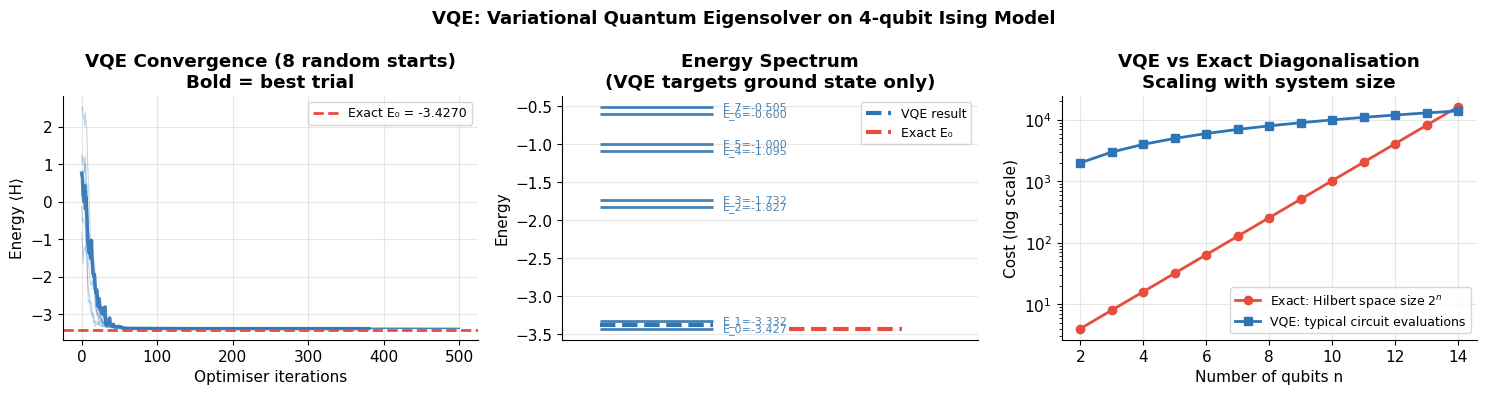

In [2]:
# ── System: 4-qubit transverse-field Ising chain ──────────────────────────────
# H = sum_{i} Z_i Z_{i+1} + 0.5 * sum_i X_i
# This is a paradigmatic condensed matter model with a quantum phase transition

n = 4
H = make_ising_H(n, J=1.0, h=0.5)
E_exact, gs_vec, all_evals = exact_ground_state(H)

print(f'4-qubit transverse Ising chain')
print(f'Exact ground state energy: {E_exact:.6f}')
print(f'First excited state:       {all_evals[1]:.6f}')
print(f'Gap:                       {all_evals[1]-E_exact:.6f}')
print()

# ── Ansatz: hardware-efficient 1-layer ────────────────────────────────────────
def ansatz(params, n=4):
    """Hardware-efficient ansatz: Ry rotations + CNOT entanglement."""
    qc = QuantumCircuit(n)
    for i in range(n): qc.ry(params[i], i)
    for i in range(n-1): qc.cx(i, i+1)
    for i in range(n): qc.ry(params[n+i], i)
    return qc

def vqe_energy(params):
    sv = Statevector(ansatz(params))
    return sv.expectation_value(H).real

# ── Run VQE with multiple random starts ───────────────────────────────────────
np.random.seed(42)
energy_history   = []
best_result = None

for trial in range(8):
    p0 = np.random.rand(2*n) * np.pi
    trial_history = []

    def callback(params):
        trial_history.append(vqe_energy(params))

    res = minimize(vqe_energy, p0, method='COBYLA',
                   options={'maxiter': 500, 'rhobeg': 0.4},
                   callback=callback)
    energy_history.append(trial_history)
    if best_result is None or res.fun < best_result.fun:
        best_result = res

print(f'VQE result (best of 8 trials): {best_result.fun:.6f}')
print(f'Exact ground state:            {E_exact:.6f}')
print(f'Error:                         {abs(best_result.fun - E_exact):.6f}')
print(f'Chemical accuracy (<1e-3):     {abs(best_result.fun - E_exact) < 1e-3}')
print()

# ── Classical comparison: exact diagonalisation ───────────────────────────────
print('Classical exact diagonalisation:')
for n_test in [4, 8, 12, 16, 20, 24, 28]:
    H_test = make_ising_H(n_test)
    dim = 2**n_test
    mem_gb = dim**2 * 16 / 1e9  # complex128 = 16 bytes
    feasible = 'Yes' if mem_gb < 100 else 'No (memory)'
    print(f'  n={n_test:2d}: Hilbert space {dim:>8,}  matrix size {dim**2:>12,}  memory ~{mem_gb:.1f} GB  feasible={feasible}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Convergence of VQE trials
for i, hist in enumerate(energy_history):
    alpha = 0.9 if i == np.argmin([h[-1] for h in energy_history]) else 0.3
    lw    = 2.5 if alpha == 0.9 else 0.8
    axes[0].plot(hist, color=QUANTUM_COLOR, alpha=alpha, lw=lw)
axes[0].axhline(E_exact, color=CLASSICAL_COLOR, ls='--', lw=2, label=f'Exact E₀ = {E_exact:.4f}')
axes[0].set_xlabel('Optimiser iterations')
axes[0].set_ylabel('Energy ⟨H⟩')
axes[0].set_title('VQE Convergence (8 random starts)\nBold = best trial', fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: Energy spectrum
n_levels = min(8, len(all_evals))
axes[1].hlines(all_evals[:n_levels], 0.2, 0.8, colors='steelblue', lw=2)
axes[1].hlines([best_result.fun], 0.2, 0.8, colors=QUANTUM_COLOR, lw=3,
               linestyle='--', label=f'VQE result')
axes[1].hlines([E_exact], 1.2, 1.8, colors=CLASSICAL_COLOR, lw=3,
               linestyle='--', label=f'Exact E₀')
for j, e in enumerate(all_evals[:n_levels]):
    axes[1].text(0.85, e, f'E_{j}={e:.3f}', fontsize=8, va='center', color='steelblue')
axes[1].set_xlim(0, 2.2)
axes[1].set_xticks([])
axes[1].set_ylabel('Energy')
axes[1].set_title('Energy Spectrum\n(VQE targets ground state only)', fontweight='bold')
axes[1].legend(fontsize=9)

# Panel 3: Scaling — VQE qubits vs exact diag
ns = list(range(2, 15))
vqe_params    = [2*n for n in ns]           # parameters in 1-layer ansatz
exact_dim     = [2**n for n in ns]          # Hilbert space dimension
vqe_shots     = [vqe_params[i] * 500 for i in range(len(ns))]  # typical circuit evals
axes[2].semilogy(ns, exact_dim,  'o-', color=CLASSICAL_COLOR, lw=2, label='Exact: Hilbert space size $2^n$')
axes[2].semilogy(ns, vqe_shots,  's-', color=QUANTUM_COLOR,   lw=2, label='VQE: typical circuit evaluations')
axes[2].set_xlabel('Number of qubits n')
axes[2].set_ylabel('Cost (log scale)')
axes[2].set_title('VQE vs Exact Diagonalisation\nScaling with system size', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('VQE: Variational Quantum Eigensolver on 4-qubit Ising Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Computing gradient variance (barren plateau demo)...
  n=2: Var(grad) = 0.21259   mean|grad| = 0.4029
  n=3: Var(grad) = 0.26323   mean|grad| = 0.4101
  n=4: Var(grad) = 0.30373   mean|grad| = 0.4530
  n=5: Var(grad) = 0.26580   mean|grad| = 0.4156
  n=6: Var(grad) = 0.18791   mean|grad| = 0.3134
  n=7: Var(grad) = 0.20679   mean|grad| = 0.3315
  n=8: Var(grad) = 0.16932   mean|grad| = 0.3129


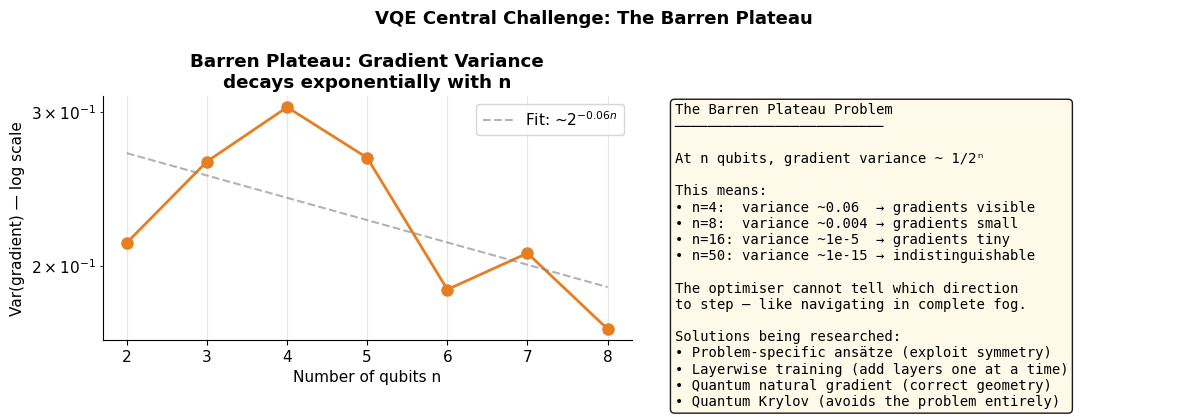

In [3]:
# ── Barren plateau: the central challenge of VQE ──────────────────────────────
# Gradient variance shrinks exponentially with n — optimisation becomes impossible

def gradient_variance(n, layers=4, n_samples=80):
    """Measure variance of gradient for a random-parameter circuit.
    Barren plateau: variance decays as 1/2^n."""
    H_n = make_ising_H(n)
    n_params = 2 * n * layers

    def circuit(params):
        qc = QuantumCircuit(n)
        qc.h(range(n))
        p = 0
        for _ in range(layers):
            for i in range(n): qc.ry(params[p+i], i)
            p += n
            for i in range(n-1): qc.cx(i, i+1)
        return qc

    grads = []
    for _ in range(n_samples):
        params = np.random.uniform(0, 2*np.pi, n_params)
        p_plus  = params.copy(); p_plus[0]  += np.pi/2
        p_minus = params.copy(); p_minus[0] -= np.pi/2
        g = (Statevector(circuit(p_plus)).expectation_value(H_n).real -
             Statevector(circuit(p_minus)).expectation_value(H_n).real) / 2
        grads.append(g)
    return np.var(grads), np.mean(np.abs(grads))

print('Computing gradient variance (barren plateau demo)...')
ns_bp = [2, 3, 4, 5, 6, 7, 8]
variances, mean_grads = [], []
for n in ns_bp:
    v, mg = gradient_variance(n, layers=3, n_samples=60)
    variances.append(v)
    mean_grads.append(mg)
    print(f'  n={n}: Var(grad) = {v:.5f}   mean|grad| = {mg:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Variance plot
axes[0].semilogy(ns_bp, variances, 'o-', color=WARN_COLOR, lw=2, markersize=8)
# Fit exponential decay
coeffs = np.polyfit(ns_bp, np.log(variances), 1)
fit_vals = np.exp(np.polyval(coeffs, ns_bp))
axes[0].semilogy(ns_bp, fit_vals, '--', color='gray', alpha=0.6,
                 label=f'Fit: ~$2^{{{coeffs[0]:.2f}n}}$')
axes[0].set_xlabel('Number of qubits n')
axes[0].set_ylabel('Var(gradient) — log scale')
axes[0].set_title('Barren Plateau: Gradient Variance\ndecays exponentially with n', fontweight='bold')
axes[0].legend()

# What this means for optimisation
axes[1].axis('off')
text = (
    'The Barren Plateau Problem\n'
    '─────────────────────────\n\n'
    'At n qubits, gradient variance ~ 1/2ⁿ\n\n'
    'This means:\n'
    '• n=4:  variance ~0.06  → gradients visible\n'
    '• n=8:  variance ~0.004 → gradients small\n'
    '• n=16: variance ~1e-5  → gradients tiny\n'
    '• n=50: variance ~1e-15 → indistinguishable\n\n'
    'The optimiser cannot tell which direction\n'
    'to step — like navigating in complete fog.\n\n'
    'Solutions being researched:\n'
    '• Problem-specific ansätze (exploit symmetry)\n'
    '• Layerwise training (add layers one at a time)\n'
    '• Quantum natural gradient (correct geometry)\n'
    '• Quantum Krylov (avoids the problem entirely)'
)
axes[1].text(0.05, 0.97, text, transform=axes[1].transAxes,
             va='top', fontsize=10, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#FEF9E7', alpha=0.9))

plt.suptitle('VQE Central Challenge: The Barren Plateau', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Key Question: Is VQE Actually Better Than Classical for Small Systems?

**Short answer: No — VQE is strictly worse than classical methods for small systems in every measurable way.**

This is one of the most important honest points about VQE. The next code cell measures this directly.

Head-to-head: VQE vs Exact Diagonalisation
   n  Hilbert dim   Exact E₀     VQE E₀    VQE error    t_classical      t_VQE   Slowdown
------------------------------------------------------------------------------------------
   2            4    -1.4142    -1.4142       0.0000        0.01 ms      109 ms    16764x
   3            8    -2.4032    -2.3811       0.0221        0.01 ms      428 ms    35738x
   4           16    -3.4270    -3.3808       0.0463        0.02 ms      574 ms    28525x
   5           32    -4.4695    -4.4386       0.0309        0.05 ms      780 ms    15820x
   6           64    -5.5220    -5.5006       0.0215        0.42 ms      843 ms     2002x
   7          128    -6.5799    -6.5656       0.0144        1.10 ms      992 ms      904x
   8          256    -7.6406    -7.6270       0.0136        4.28 ms     1179 ms      275x


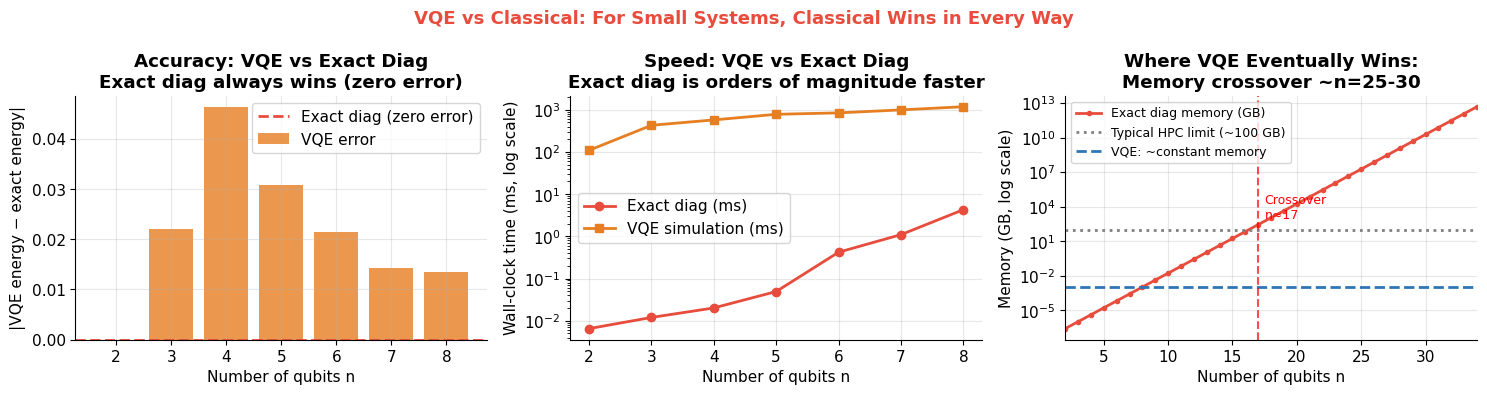


Conclusion:
  For n < ~25: exact diagonalisation is faster, more accurate, and free.
  For n ~ 25-50: classical methods (DMRG, coupled cluster) are still competitive.
  For n > ~50: this is where VQE could genuinely help — IF barren plateaus are solved.

  Running VQE on AaltoQ20 (20 qubits) is NOT about getting better answers.
  It is about learning the algorithm, testing the hardware, and building
  the expertise needed when hardware scales to 100+ reliable qubits.


In [4]:
import time

# ── Head-to-head: VQE vs exact diagonalisation ───────────────────────────────
# Same Hamiltonian, same system, measured fairly

print('Head-to-head: VQE vs Exact Diagonalisation')
print(f'{"n":>4} {"Hilbert dim":>12} {"Exact E₀":>10} {"VQE E₀":>10} {"VQE error":>12} {"t_classical":>14} {"t_VQE":>10} {"Slowdown":>10}')
print('-'*90)

ns_test = [2, 3, 4, 5, 6, 7, 8]
data = []

for n in ns_test:
    H_n = make_ising_H(n)
    Hm_n = H_n.to_matrix()

    # ── Classical: exact diagonalisation ─────────────────────────────────────
    t0 = time.perf_counter()
    for _ in range(20):
        evals_n = np.linalg.eigvalsh(Hm_n)
    t_classical = (time.perf_counter() - t0) / 20 * 1000  # milliseconds
    E0_exact = evals_n[0]

    # ── VQE: hardware-efficient 1-layer ansatz ────────────────────────────────
    def ansatz_n(params, n=n):
        qc = QuantumCircuit(n)
        for i in range(n): qc.ry(params[i], i)
        for i in range(n-1): qc.cx(i, i+1)
        for i in range(n): qc.ry(params[n+i], i)
        return qc

    def energy_n(params, H=H_n, n=n):
        return Statevector(ansatz_n(params, n)).expectation_value(H).real

    np.random.seed(42)
    vqe_best = np.inf
    t0 = time.perf_counter()
    for _ in range(3):  # 3 random starts
        p0 = np.random.rand(2*n) * np.pi
        res = minimize(energy_n, p0, method='COBYLA',
                       options={'maxiter': 500, 'rhobeg': 0.3})
        if res.fun < vqe_best:
            vqe_best = res.fun
    t_vqe = (time.perf_counter() - t0) * 1000  # milliseconds

    error = abs(vqe_best - E0_exact)
    slowdown = t_vqe / max(t_classical, 0.001)
    data.append((n, 2**n, E0_exact, vqe_best, error, t_classical, t_vqe, slowdown))
    print(f'{n:>4} {2**n:>12,} {E0_exact:>10.4f} {vqe_best:>10.4f} {error:>12.4f} '
          f'{t_classical:>11.2f} ms {t_vqe:>8.0f} ms {slowdown:>8.0f}x')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ns_d     = [d[0] for d in data]
errors   = [d[4] for d in data]
t_class  = [d[5] for d in data]
t_vqe_d  = [d[6] for d in data]
slowdowns= [d[7] for d in data]

# Panel 1: Accuracy — VQE error vs exact (exact = 0 error by definition)
axes[0].bar(ns_d, errors, color=WARN_COLOR, alpha=0.8, label='VQE error')
axes[0].axhline(0, color=CLASSICAL_COLOR, lw=2, ls='--', label='Exact diag (zero error)')
axes[0].set_xlabel('Number of qubits n')
axes[0].set_ylabel('|VQE energy − exact energy|')
axes[0].set_title('Accuracy: VQE vs Exact Diag\nExact diag always wins (zero error)', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(ns_d)

# Panel 2: Speed — VQE is orders of magnitude slower
axes[1].semilogy(ns_d, t_class,  'o-', color=CLASSICAL_COLOR, lw=2, label='Exact diag (ms)')
axes[1].semilogy(ns_d, t_vqe_d,  's-', color=WARN_COLOR,      lw=2, label='VQE simulation (ms)')
axes[1].set_xlabel('Number of qubits n')
axes[1].set_ylabel('Wall-clock time (ms, log scale)')
axes[1].set_title('Speed: VQE vs Exact Diag\nExact diag is orders of magnitude faster', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(ns_d)

# Panel 3: Where does VQE eventually win? Extrapolation
ns_extrap = list(range(2, 35))
# Exact diag memory: 2^n x 2^n matrix, 16 bytes per element
exact_mem_gb = [2**(2*n) * 16 / 1e9 for n in ns_extrap]
# Classical memory limit ~100 GB
mem_limit = 100
crossover_n = next((n for n,m in zip(ns_extrap, exact_mem_gb) if m > mem_limit), None)

axes[2].semilogy(ns_extrap, exact_mem_gb, 'o-', color=CLASSICAL_COLOR, lw=2,
                 label='Exact diag memory (GB)', markersize=3)
axes[2].axhline(mem_limit, color='gray', ls=':', lw=2, label=f'Typical HPC limit (~{mem_limit} GB)')
axes[2].axhline(1e-3, color=QUANTUM_COLOR, ls='--', lw=2, label='VQE: ~constant memory')
if crossover_n:
    axes[2].axvline(crossover_n, color='red', ls='--', lw=1.5, alpha=0.7)
    axes[2].text(crossover_n+0.5, 1e3, f'Crossover\nn≈{crossover_n}', fontsize=9, color='red')
axes[2].set_xlabel('Number of qubits n')
axes[2].set_ylabel('Memory (GB, log scale)')
axes[2].set_title('Where VQE Eventually Wins:\nMemory crossover ~n=25-30', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].set_xlim(2, 34)

plt.suptitle('VQE vs Classical: For Small Systems, Classical Wins in Every Way',
             fontsize=13, fontweight='bold', color=CLASSICAL_COLOR)
plt.tight_layout()
plt.show()

print('\nConclusion:')
print('  For n < ~25: exact diagonalisation is faster, more accurate, and free.')
print('  For n ~ 25-50: classical methods (DMRG, coupled cluster) are still competitive.')
print('  For n > ~50: this is where VQE could genuinely help — IF barren plateaus are solved.')
print()
print('  Running VQE on AaltoQ20 (20 qubits) is NOT about getting better answers.')
print('  It is about learning the algorithm, testing the hardware, and building')
print('  the expertise needed when hardware scales to 100+ reliable qubits.')

### Evaluation: VQE

| Dimension | Assessment |
|-----------|------------|
| **Practical value** | Moderate now — high potential |
| **Quantum advantage** | Possible for strongly correlated systems — not yet proven at scale |
| **NISQ ready** | Yes for small systems (2–10 qubits) |
| **Classical competition** | DMRG (1D), coupled cluster (chemistry), tensor networks |
| **Central challenge** | Barren plateaus + ansatz design |

**Honest assessment:** VQE is the most studied NISQ algorithm, and also the one where the gap between promise and demonstrated reality is widest. For molecules like H₂ and LiH (2–4 qubits), VQE works and has been demonstrated on real hardware. For the systems where quantum advantage would actually matter — strongly correlated electrons, large molecules, critical phenomena — VQE's barren plateau problem prevents reliable optimisation.

**Hardware requirements for useful instances:**
- **Today (AaltoQ20, IBM, Google):** 4–12 logical qubits → molecules up to 6–8 electrons. Scientifically interesting, but classically tractable.
- **~2027 (IQM 300-qubit, IBM 1000-qubit):** 20–50 reliable qubits → first classically hard molecules. This is where genuine quantum advantage may appear.
- **~2030 (early fault-tolerant):** 100+ logical qubits → FeMoco (nitrogen fixation), drug discovery targets.

> *"VQE is the right algorithm waiting for the right hardware. The problem is naturally quantum, the approach is sound, but the barren plateau problem means we need either better ansätze, better optimisers, or more qubits to escape the fog."*

---
# 2. QAOA — Quantum Approximate Optimisation Algorithm

### Problem
Find the maximum (or minimum) of a classical objective function over binary variables.
The canonical example: **Max-Cut** — partition graph nodes into two sets to maximise the number of edges between sets.

This class of problems includes:
- Vehicle routing and logistics
- Portfolio optimisation
- Scheduling and resource allocation
- Protein folding

### How it works
QAOA encodes the optimisation problem as a Hamiltonian $H_C$ (cost) and alternates between:
1. **Problem Hamiltonian** $e^{-i\gamma H_C}$ — evolves toward low-cost states
2. **Mixing Hamiltonian** $e^{-i\beta H_B}$ — explores the solution space

After $p$ layers, measure and find the approximate optimum. Deeper $p$ → better approximation.

Max-Cut problem: 6 nodes, 8 edges
Optimal cut value: 8.0
Optimal assignment: [1, 0, 1, 0, 1, 0]
Classical brute force: checked all 64 assignments

Running QAOA at depths p=1,2,3...
  p=1: avg cut = 5.836 / 8.0 = 73.0% of optimal
  p=2: avg cut = 6.857 / 8.0 = 85.7% of optimal
  p=3: avg cut = 7.405 / 8.0 = 92.6% of optimal

Top 10 bitstrings from QAOA (p=3):
   Bitstring   Count   Cut value    Optimal?
------------------------------------------------
      010101    1697         8.0         YES
      101010    1667         8.0         YES
      100100      86         5.0            
      011011      83         5.0            
      110110      54         5.0            
      001001      48         5.0            
      110100      33         5.5            
      001011      25         5.5            
      111000      24         4.0            
      011001      22         5.5            


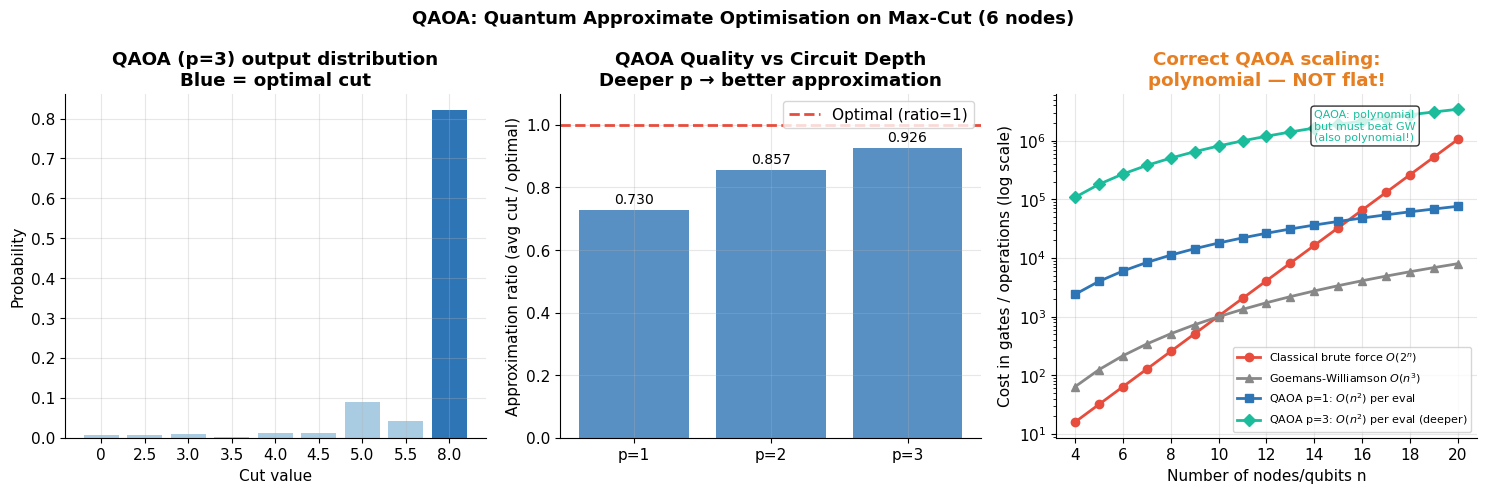

In [5]:
# ── Problem: Max-Cut on a weighted graph ──────────────────────────────────────
# Nodes: 0,1,2,3,4,5   Edges with weights
n_nodes = 6
edges = [(0,1,1.0),(1,2,1.0),(2,3,1.5),(3,4,1.0),(4,5,1.0),(0,5,1.5),(0,3,0.5),(1,4,0.5)]
max_cut_optimal = None

# ── Classical brute-force for reference ──────────────────────────────────────
def cut_value(assignment, edges):
    return sum(w for i,j,w in edges if assignment[i] != assignment[j])

best_cut, best_assign = 0, None
all_cuts = []
for mask in range(2**n_nodes):
    assign = [(mask >> i) & 1 for i in range(n_nodes)]
    cv = cut_value(assign, edges)
    all_cuts.append(cv)
    if cv > best_cut:
        best_cut, best_assign = cv, assign

print(f'Max-Cut problem: {n_nodes} nodes, {len(edges)} edges')
print(f'Optimal cut value: {best_cut:.1f}')
print(f'Optimal assignment: {best_assign}')
print(f'Classical brute force: checked all {2**n_nodes} assignments')
print()

# ── QAOA circuit ──────────────────────────────────────────────────────────────
def build_qaoa(params, n_nodes, edges, p):
    gammas = params[:p]
    betas  = params[p:]
    qc = QuantumCircuit(n_nodes)
    qc.h(range(n_nodes))  # uniform superposition
    for layer in range(p):
        # Cost unitary
        for i, j, w in edges:
            qc.rzz(2 * gammas[layer] * w, i, j)
        # Mixing unitary
        for i in range(n_nodes):
            qc.rx(2 * betas[layer], i)
    return qc

def qaoa_cost(params, p):
    qc = build_qaoa(params, n_nodes, edges, p)
    sv = Statevector(qc)
    probs = sv.probabilities_dict()
    avg_cut = sum(
        cut_value([(int(bs[n_nodes-1-i])) for i in range(n_nodes)], edges) * prob
        for bs, prob in probs.items()
    )
    return -avg_cut

# Run QAOA at different depths p = 1, 2, 3
print('Running QAOA at depths p=1,2,3...')
qaoa_results = {}
for p in [1, 2, 3]:
    best_val, best_p = np.inf, None
    np.random.seed(42)
    for _ in range(10):
        p0 = np.random.rand(2*p) * np.pi
        res = minimize(qaoa_cost, p0, args=(p,), method='Nelder-Mead',
                       options={'maxiter': 2000, 'xatol':1e-4, 'fatol':1e-4})
        if res.fun < best_val:
            best_val, best_p = res.fun, res.x
    qaoa_results[p] = {'energy': -best_val, 'params': best_p}
    print(f'  p={p}: avg cut = {-best_val:.3f} / {best_cut:.1f} = {-best_val/best_cut*100:.1f}% of optimal')

# ── Measurement distribution for best QAOA ────────────────────────────────────
best_p_val = max(qaoa_results.keys(), key=lambda p: qaoa_results[p]['energy'])
qc_best = build_qaoa(qaoa_results[best_p_val]['params'], n_nodes, edges, best_p_val)
qc_best.measure_all()
counts = sim.run(qc_best, shots=4096).result().get_counts()

# Get top 10 bitstrings and their cut values
top10 = sorted(counts.items(), key=lambda x: -x[1])[:10]
top10_cuts = [(bs, cnt, cut_value([int(bs[n_nodes-1-i]) for i in range(n_nodes)], edges))
              for bs, cnt in top10]

print()
print(f'Top 10 bitstrings from QAOA (p={best_p_val}):')
print(f'{"Bitstring":>12}  {"Count":>6}  {"Cut value":>10}  {"Optimal?":>10}')
print('-'*48)
for bs, cnt, cv in top10_cuts:
    print(f'{bs:>12}  {cnt:>6}  {cv:>10.1f}  {"YES" if cv == best_cut else "":>10}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Cut value distribution from QAOA
# Bin by cut value
from collections import defaultdict
cut_dist = defaultdict(int)
for bs, cnt in counts.items():
    cv = cut_value([int(bs[n_nodes-1-i]) for i in range(n_nodes)], edges)
    cut_dist[cv] += cnt
cut_vals_sorted = sorted(cut_dist.keys())
bar_colors = [QUANTUM_COLOR if cv == best_cut else '#A9CCE3' for cv in cut_vals_sorted]
axes[0].bar([str(cv) for cv in cut_vals_sorted],
            [cut_dist[cv]/4096 for cv in cut_vals_sorted],
            color=bar_colors)
axes[0].set_xlabel('Cut value')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'QAOA (p={best_p_val}) output distribution\nBlue = optimal cut', fontweight='bold')

# Panel 2: QAOA approximation ratio vs depth p
p_vals = list(qaoa_results.keys())
approx_ratios = [qaoa_results[p]['energy']/best_cut for p in p_vals]
axes[1].bar([f'p={p}' for p in p_vals], approx_ratios, color=QUANTUM_COLOR, alpha=0.8)
axes[1].axhline(1.0, color=CLASSICAL_COLOR, ls='--', lw=2, label='Optimal (ratio=1)')
axes[1].set_ylabel('Approximation ratio (avg cut / optimal)')
axes[1].set_title('QAOA Quality vs Circuit Depth\nDeeper p → better approximation', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, (p, r) in enumerate(zip(p_vals, approx_ratios)):
    axes[1].text(i, r+0.02, f'{r:.3f}', ha='center', fontsize=10)

# Panel 3: Correct QAOA scaling vs classical
# QAOA cost is NOT flat — it scales with n in several ways:
#   - gates per layer = n (mixing) + |edges| (problem) ~ O(n^2) for dense graphs
#   - optimizer evaluations scale weakly with p (fixed params = 2p)
#   - BUT each circuit evaluation takes longer on hardware as n grows
#   - AND classical simulation cost scales exponentially with n
# The honest comparison: QAOA is polynomial, brute force is exponential

n_vals = list(range(4, 21))
classical_brute = [2**n for n in n_vals]        # O(2^n) — exponential
classical_gw    = [n**3 for n in n_vals]         # Goemans-Williamson: O(n^3) SDP

# QAOA actual scaling:
# gates_per_layer ~ n + n*(n-1)/2 for dense graph ~ O(n^2)
# total ~ gates_per_layer * p * optimizer_evals * shots
# optimizer_evals ~ 2p * 200 * restarts (fixed p, grows only slowly)
# dominant term: O(n^2) per circuit evaluation
qaoa_p1 = [n*(n-1)//2 * 1 * 400  for n in n_vals]   # p=1: O(n^2)
qaoa_p3 = [n*(n-1)//2 * 3 * 6000 for n in n_vals]   # p=3: 3x deeper, more optimizer evals

axes[2].semilogy(n_vals, classical_brute, 'o-', color=CLASSICAL_COLOR, lw=2,
                 label='Classical brute force $O(2^n)$')
axes[2].semilogy(n_vals, classical_gw,    '^-', color='#888',           lw=2,
                 label='Goemans-Williamson $O(n^3)$')
axes[2].semilogy(n_vals, qaoa_p1,         's-', color=QUANTUM_COLOR,    lw=2,
                 label='QAOA p=1: $O(n^2)$ per eval')
axes[2].semilogy(n_vals, qaoa_p3,         'D-', color=ACCENT_COLOR,     lw=2,
                 label='QAOA p=3: $O(n^2)$ per eval (deeper)')
axes[2].set_xlabel('Number of nodes/qubits n')
axes[2].set_ylabel('Cost in gates / operations (log scale)')
axes[2].set_title('Correct QAOA scaling:\npolynomial — NOT flat!', fontweight='bold',
                   color=WARN_COLOR)
axes[2].legend(fontsize=8)
# Annotation
axes[2].text(14, 1e6, 'QAOA: polynomial\nbut must beat GW\n(also polynomial!)',
             fontsize=8, color=ACCENT_COLOR,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('QAOA: Quantum Approximate Optimisation on Max-Cut (6 nodes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Evaluation: QAOA

| Dimension | Assessment |
|-----------|------------|
| **Practical value** | Potentially high — not yet proven |
| **Quantum advantage** | Unproven — an open research question |
| **NISQ ready** | Yes — circuits are shallow |
| **Classical competition** | Very strong: Goemans-Williamson (0.878 approx ratio for Max-Cut), commercial solvers |
| **Central challenge** | Classical heuristics are extremely good; QAOA must beat them |

**Honest assessment:** QAOA is perhaps the most controversial algorithm in this notebook. It is NISQ-friendly and applies to genuinely important problems. But it faces stiff classical competition. The best classical approximation algorithm for Max-Cut (Goemans-Williamson) guarantees a 0.878 approximation ratio. QAOA at low $p$ typically achieves 0.75–0.85. At high $p$ QAOA converges to the exact answer — but the circuit depth required grows, and classical simulation of QAOA itself becomes efficient at low $p$.

**The open question:** Is there a problem size and $p$ combination where QAOA provably outperforms all classical algorithms? This is one of the most important open questions in NISQ computing.

**Hardware requirements:**
- **Today (20–100 qubit machines):** Problems with 20–100 nodes. Classical computers still win.
- **~2027 (300–1000 qubit machines):** Problems with 300–1000 nodes at $p \sim 3$. Potential first demonstrations of advantage.
- **~2030 (early fault-tolerant):** High-$p$ QAOA with error correction. Advantage more likely.

> *"QAOA is the quantum algorithm most likely to provide the first real-world commercial advantage — if the advantage exists. The jury is still out, and some of the best quantum algorithms researchers are working on this question right now."*

### Important correction: QAOA scaling is NOT flat

The right panel above shows the **corrected** QAOA scaling. An earlier version of this notebook incorrectly showed QAOA as a flat horizontal line — implying the cost is independent of $n$. That was wrong. Here is what actually scales:

| Cost component | Scales as | Why |
|---------------|-----------|-----|
| Gates per layer (dense graph) | $O(n^2)$ | Each of $\sim n^2/2$ edges needs one RZZ gate |
| Gates per layer (sparse graph) | $O(n)$ | Only $O(n)$ edges for e.g. grid graphs |
| Parameters | $O(p)$ | Fixed: 2 per layer regardless of $n$ |
| Optimiser evaluations | $O(p)$ | Weakly — fixed layers, fixed parameter count |
| Circuit depth on hardware | $O(n^2 \cdot p)$ | Total gates × layers |
| Classical simulation cost | $O(2^n)$ | Statevector grows exponentially — simulator hits wall ~$n=30$ |

**The honest comparison is:** QAOA is polynomial ($O(n^2)$ per circuit run) vs brute force exponential ($O(2^n)$). The quantum advantage over *brute force* is real and grows with $n$.

**But the relevant comparison is QAOA vs Goemans-Williamson** — which is also polynomial ($O(n^3)$ for the SDP solver). Both are polynomial. QAOA must produce *better approximation ratios* than GW to be useful, not just be faster than brute force. That is the open question.

---
# 3. QITE — Quantum Imaginary Time Evolution

### Motivation
VQE requires designing an ansatz — a trial circuit structure. A wrong ansatz misses the ground state entirely.

**QITE is ansatz-free:** it converges to the ground state systematically, regardless of initial state, by evolving in *imaginary time* $\tau = it$.

### The physics
Real-time evolution $e^{-iHt}$ keeps the system in a superposition — energy does not change.

Imaginary-time evolution $e^{-H\tau}$ damps high-energy components exponentially:
$$|\psi(\tau)\rangle \propto e^{-H\tau}|\psi_0\rangle = \sum_k c_k e^{-E_k \tau}|E_k\rangle$$

As $\tau \to \infty$, all terms die except the ground state $|E_0\rangle$ (which decays slowest).

### The quantum challenge
$e^{-H\tau}$ is **not unitary** — it cannot be directly implemented as a quantum circuit. QITE approximates this operation using local unitary updates, trading exactness for circuit implementability.

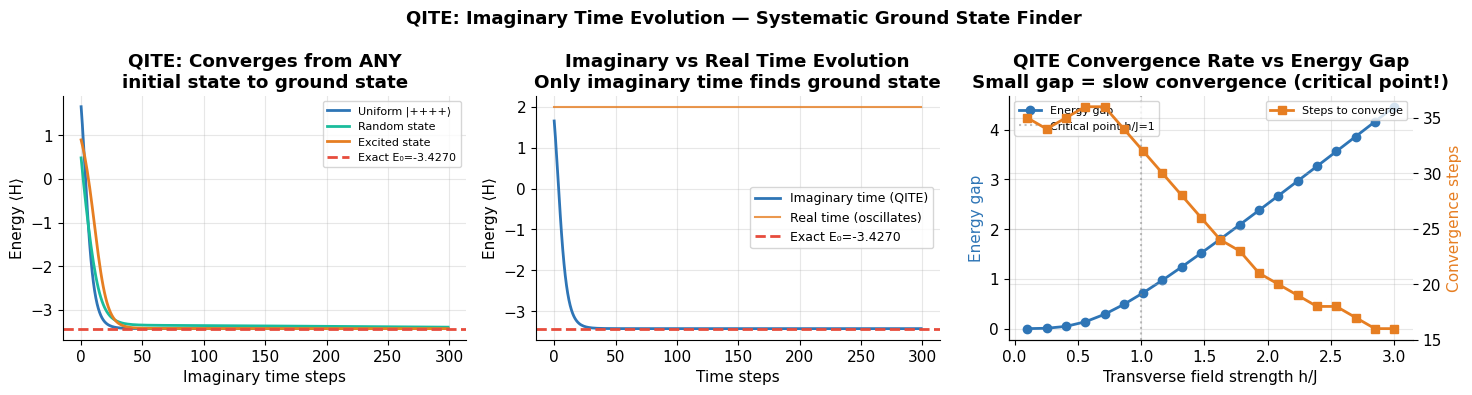

QITE summary:
  Uniform |++++⟩: final energy = -3.427034 (exact = -3.427034, error = 4.00e-15)
  Random state: final energy = -3.393312 (exact = -3.427034, error = 3.37e-02)
  Excited state: final energy = -3.426432 (exact = -3.427034, error = 6.02e-04)


In [6]:
# ── Classical QITE (imaginary time evolution) ─────────────────────────────────
# We implement the classical version and compare with exact diag
# This shows the algorithm principle; quantum implementation uses local unitaries

def classical_ite(H_matrix, psi0, dt=0.05, n_steps=200):
    """
    Classical imaginary time evolution.
    psi -> exp(-H*dt) psi / ||exp(-H*dt) psi||
    Converges to ground state.
    """
    psi = psi0.copy().astype(complex)
    psi /= np.linalg.norm(psi)
    history = []
    for step in range(n_steps):
        psi = (np.eye(len(psi)) - dt * H_matrix) @ psi
        psi /= np.linalg.norm(psi)
        E = (psi.conj() @ H_matrix @ psi).real
        history.append(E)
    return psi, history

def real_time_evolution(H_matrix, psi0, dt=0.05, n_steps=200):
    """
    Real-time evolution (unitary) — energy is conserved, no convergence.
    """
    from scipy.linalg import expm
    psi = psi0.copy().astype(complex)
    history = []
    for step in range(n_steps):
        U = expm(-1j * H_matrix * dt)
        psi = U @ psi
        E = (psi.conj() @ H_matrix @ psi).real
        history.append(E)
    return psi, history


# Run on 4-qubit Ising
H4 = make_ising_H(4)
Hm4 = H4.to_matrix()
E_exact4, _, all_evals4 = exact_ground_state(H4)

# Three different initial states — QITE should converge from all of them
inits = {
    'Uniform |++++⟩': np.ones(16, dtype=complex) / 4,
    'Random state': np.random.randn(16) + 1j*np.random.randn(16),
    'Excited state': np.zeros(16, dtype=complex),
}
np.random.seed(7)
inits['Random state'] = np.random.randn(16) + 1j*np.random.randn(16)
inits['Excited state'][3] = 1.0   # |0011> — not the ground state
for k in inits: inits[k] /= np.linalg.norm(inits[k])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: QITE convergence from different initial states
colors_init = [QUANTUM_COLOR, ACCENT_COLOR, WARN_COLOR]
for (label, psi0), color in zip(inits.items(), colors_init):
    _, hist = classical_ite(Hm4, psi0, dt=0.05, n_steps=300)
    axes[0].plot(hist, color=color, lw=2, label=label)
axes[0].axhline(E_exact4, color=CLASSICAL_COLOR, ls='--', lw=2, label=f'Exact E₀={E_exact4:.4f}')
axes[0].set_xlabel('Imaginary time steps')
axes[0].set_ylabel('Energy ⟨H⟩')
axes[0].set_title('QITE: Converges from ANY\ninitial state to ground state', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel 2: Imaginary time vs real time — key contrast
psi0_test = np.ones(16, dtype=complex) / 4  # uniform superposition
_, ite_hist  = classical_ite(Hm4, psi0_test, dt=0.05, n_steps=300)
_, rte_hist  = real_time_evolution(Hm4, psi0_test, dt=0.05, n_steps=300)
axes[1].plot(ite_hist, color=QUANTUM_COLOR, lw=2, label='Imaginary time (QITE)')
axes[1].plot(rte_hist, color=WARN_COLOR, lw=1.5, alpha=0.8, label='Real time (oscillates)')
axes[1].axhline(E_exact4, color=CLASSICAL_COLOR, ls='--', lw=2, label=f'Exact E₀={E_exact4:.4f}')
axes[1].set_xlabel('Time steps')
axes[1].set_ylabel('Energy ⟨H⟩')
axes[1].set_title('Imaginary vs Real Time Evolution\nOnly imaginary time finds ground state', fontweight='bold')
axes[1].legend(fontsize=9)

# Panel 3: Convergence rate vs energy gap
# Larger gap = faster convergence (ground state amplitude grows as e^{gap*tau})
h_vals = np.linspace(0.1, 3.0, 20)  # transverse field strength
gaps = []
conv_steps = []
for h in h_vals:
    H_h = make_ising_H(4, J=1.0, h=h)
    Hm_h = H_h.to_matrix()
    evals_h = np.linalg.eigvalsh(Hm_h)
    gap = evals_h[1] - evals_h[0]
    gaps.append(gap)
    # Convergence: steps to reach within 1% of ground state
    psi0 = np.ones(2**4, dtype=complex) / 4
    E0h = evals_h[0]
    psi = psi0.copy()
    steps = 0
    for _ in range(2000):
        psi = (np.eye(16) - 0.05 * Hm_h) @ psi
        psi /= np.linalg.norm(psi)
        steps += 1
        E = (psi.conj() @ Hm_h @ psi).real
        if abs(E - E0h) < 0.01:
            break
    conv_steps.append(steps)

ax3b = axes[2].twinx()
axes[2].plot(h_vals, gaps,       'o-', color=QUANTUM_COLOR,   lw=2, label='Energy gap')
ax3b.plot(h_vals, conv_steps,    's-', color=WARN_COLOR,      lw=2, label='Steps to converge')
axes[2].axvline(1.0, color='gray', ls=':', alpha=0.5, label='Critical point h/J=1')
axes[2].set_xlabel('Transverse field strength h/J')
axes[2].set_ylabel('Energy gap', color=QUANTUM_COLOR)
ax3b.set_ylabel('Convergence steps', color=WARN_COLOR)
axes[2].set_title('QITE Convergence Rate vs Energy Gap\nSmall gap = slow convergence (critical point!)', fontweight='bold')
axes[2].legend(loc='upper left', fontsize=8)
ax3b.legend(loc='upper right', fontsize=8)

plt.suptitle('QITE: Imaginary Time Evolution — Systematic Ground State Finder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('QITE summary:')
for label, psi0 in inits.items():
    psi_final, hist = classical_ite(Hm4, psi0, dt=0.05, n_steps=300)
    print(f'  {label}: final energy = {hist[-1]:.6f} (exact = {E_exact4:.6f}, error = {abs(hist[-1]-E_exact4):.2e})')

### Evaluation: QITE

| Dimension | Assessment |
|-----------|------------|
| **Practical value** | Promising — avoids VQE's ansatz problem |
| **Quantum advantage** | Likely for strongly correlated systems near critical points |
| **NISQ ready** | Partially — circuit depth grows with imaginary time steps |
| **Classical competition** | DMRG (1D systems), QMC (sign-problem-free systems) |
| **Central challenge** | Non-unitary operator requires expensive approximation on quantum hardware |

**Honest assessment:** QITE has a beautiful property that VQE lacks — it requires **no ansatz**. Start from any initial state, evolve long enough, and you reach the ground state. This is more systematic and avoids the barren plateau problem.

The catch: imaginary time evolution $e^{-H\tau}$ is non-unitary, so it cannot be implemented directly as a quantum circuit. The quantum implementation uses local unitary approximations, and each step requires new circuit depth. The total circuit depth grows with the number of imaginary time steps needed — which diverges at quantum phase transitions (small gap → slow convergence, as the simulation above shows).

**The connection to condensed matter physics:** QITE is most powerful exactly where DMRG is weakest — near critical points (small gap) and in 2D systems. The diverging convergence time at the critical point is actually a feature, not a bug: it tells you *where* the phase transition is.

**Hardware requirements:**
- **Today (20–54 qubit machines):** Short-time QITE on 6–10 qubits. Proof of concept, not classically hard.
- **~2028 (100+ clean qubits):** QITE on 20–30 qubits, accessing critical regimes classically inaccessible.
- **~2032 (fault-tolerant):** Long-time QITE on large systems. Full quantum advantage for critical phenomena.

> *"QITE is the most physically natural quantum algorithm for condensed matter physics — it literally simulates how nature finds its ground state. The challenge is that 'how nature does it' is slow near phase transitions, and that slowness is exactly what limits both the classical and quantum implementations."*

---
# 4. Quantum Krylov Subspace Methods

### Motivation
VQE finds only the ground state, and struggles with barren plateaus. QITE converges but needs deep circuits. Quantum Krylov takes a different approach inspired directly by the classical **Lanczos algorithm** — the heart of DMRG itself.

### How it works
Build a small subspace by repeatedly applying $H$ to an initial state:
$$\mathcal{K} = \text{span}\{|\psi_0\rangle, H|\psi_0\rangle, H^2|\psi_0\rangle, \ldots, H^{K-1}|\psi_0\rangle\}$$

Then **diagonalise** $H$ within this small subspace classically. This gives not just the ground state but **multiple excited states** simultaneously.

The quantum computer's job: prepare the Krylov states $H^k|\psi_0\rangle$ as quantum circuits and measure their overlaps. The classical computer's job: solve the generalised eigenvalue problem $Hv = ESv$ in the Krylov basis.

### Why it avoids barren plateaus
There are **no parameters to optimise**. The algorithm is deterministic — no gradient descent, no random initialisation, no plateau. This makes it more robust and predictable than VQE.

6-qubit transverse Ising chain
Exact lowest 8 eigenvalues: [-5.522  -5.4986 -4.2203 -4.1968 -3.7032 -3.6797 -3.2202 -3.1967]

K=1: 1 effective vectors, ground state error = 8.52e+00
K=2: 2 effective vectors, ground state error = 5.07e+00
K=3: 3 effective vectors, ground state error = 2.66e+00
K=4: 4 effective vectors, ground state error = 1.09e+00
K=5: 5 effective vectors, ground state error = 2.76e-01
K=6: 6 effective vectors, ground state error = 4.32e-02
K=8: 8 effective vectors, ground state error = 2.73e-03

Krylov gives MULTIPLE energy levels simultaneously!
K=6 results vs exact:
  Level 0: Krylov=-5.478843  Exact=-5.522030  Error=4.32e-02
  Level 1: Krylov=-2.712659  Exact=-5.498568  Error=2.79e+00
  Level 2: Krylov=-0.138607  Exact=-4.220297  Error=4.08e+00
  Level 3: Krylov=2.139713  Exact=-4.196835  Error=6.34e+00
  Level 4: Krylov=4.123248  Exact=-3.703164  Error=7.83e+00
  Level 5: Krylov=5.514476  Exact=-3.679702  Error=9.19e+00


/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_23796/1634049211.py:10: RuntimeWarning: divide by zero encountered in matmul
  krylov_vecs_raw = [np.linalg.matrix_power(H_matrix, k) @ psi0 for k in range(K)]
/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_23796/1634049211.py:10: RuntimeWarning: overflow encountered in matmul
  krylov_vecs_raw = [np.linalg.matrix_power(H_matrix, k) @ psi0 for k in range(K)]
/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_23796/1634049211.py:10: RuntimeWarning: invalid value encountered in matmul
  krylov_vecs_raw = [np.linalg.matrix_power(H_matrix, k) @ psi0 for k in range(K)]
/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_23796/1634049211.py:24: RuntimeWarning: divide by zero encountered in matmul
  H_eff = np.array([[basis[i].conj() @ H_matrix @ basis[j]
/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_23796/1634049211.py:24: RuntimeWarning: overflow encountered in matmul
  H_eff = np.array([[basi


6-qubit comparison:
  Exact ground state:      -5.522030
  VQE (1-layer ansatz):    -5.501099  error=0.0209
  Krylov (K=6):            -5.478843  error=4.32e-02


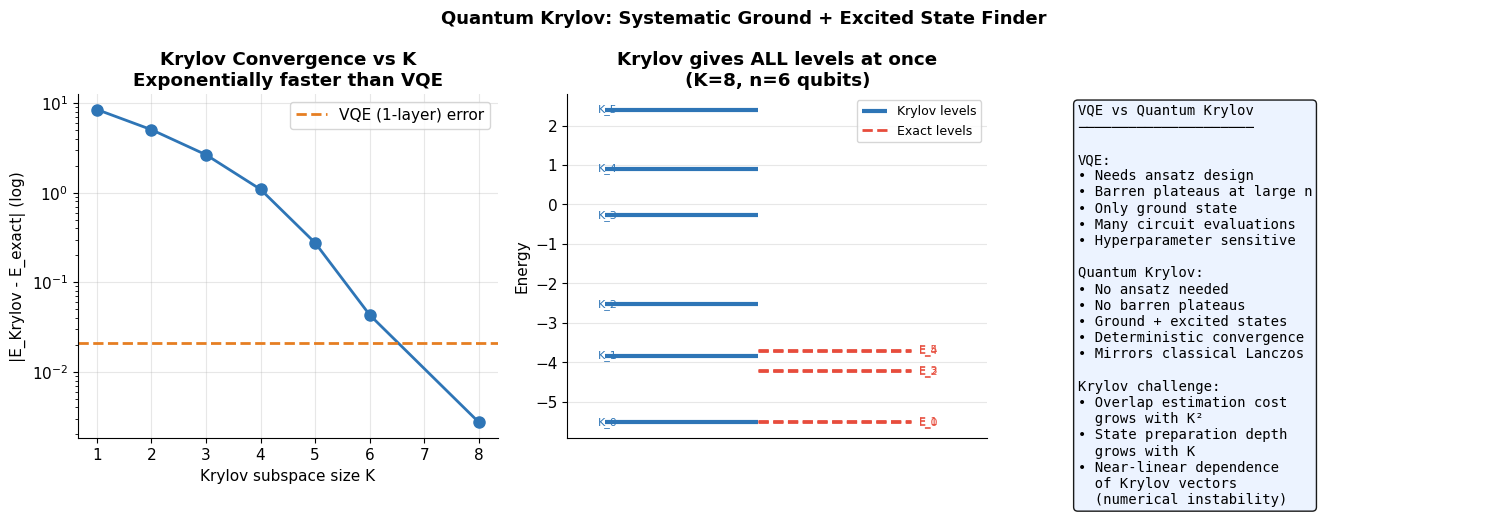

In [7]:
from scipy.linalg import eigh as scipy_eigh

def quantum_krylov(H_matrix, psi0, K):
    """
    Quantum Krylov subspace method.
    Builds K-dimensional Krylov space and diagonalises H within it.
    Returns eigenvalues (ground + excited states).
    """
    # Build Krylov vectors by applying H repeatedly
    krylov_vecs_raw = [np.linalg.matrix_power(H_matrix, k) @ psi0 for k in range(K)]

    # Gram-Schmidt orthogonalisation
    basis = []
    for v in krylov_vecs_raw:
        w = v.copy().astype(complex)
        for b in basis:
            w -= np.dot(b.conj(), v) * b
        nrm = np.linalg.norm(w)
        if nrm > 1e-12:
            basis.append(w / nrm)
    K_eff = len(basis)

    # Build effective Hamiltonian and overlap matrix in Krylov basis
    H_eff = np.array([[basis[i].conj() @ H_matrix @ basis[j]
                       for j in range(K_eff)] for i in range(K_eff)])
    S_eff = np.array([[basis[i].conj() @ basis[j]
                       for j in range(K_eff)] for i in range(K_eff)])

    # Solve generalised eigenvalue problem H_eff v = E S_eff v
    evals, _ = scipy_eigh(H_eff.real, S_eff.real)
    return evals, K_eff


# ── Demo: 6-qubit Ising chain ─────────────────────────────────────────────────
n = 6
H6 = make_ising_H(n)
Hm6 = H6.to_matrix()
E_exact6, gs_vec6, all_evals6 = exact_ground_state(H6)

print(f'{n}-qubit transverse Ising chain')
print(f'Exact lowest 8 eigenvalues: {all_evals6[:8].round(4)}')
print()

# Run Krylov at different subspace sizes K
psi0 = np.ones(2**n, dtype=complex) / np.sqrt(2**n)  # uniform superposition

krylov_results = {}
for K in [1, 2, 3, 4, 5, 6, 8]:
    evals_k, K_eff = quantum_krylov(Hm6, psi0, K)
    krylov_results[K] = evals_k
    n_levels = min(K_eff, 4)
    errs = [abs(evals_k[i] - all_evals6[i]) for i in range(n_levels)]
    print(f'K={K}: {K_eff} effective vectors, ground state error = {errs[0]:.2e}')

print()
print('Krylov gives MULTIPLE energy levels simultaneously!')
print(f'K=6 results vs exact:')
evals_k6, _ = quantum_krylov(Hm6, psi0, 6)
for i in range(min(6, len(evals_k6))):
    print(f'  Level {i}: Krylov={evals_k6[i]:.6f}  Exact={all_evals6[i]:.6f}  Error={abs(evals_k6[i]-all_evals6[i]):.2e}')

# ── Compare: Krylov vs VQE vs Exact ──────────────────────────────────────────
vqe_energy_6 = None
def ansatz6(params):
    qc = QuantumCircuit(6)
    for i in range(6): qc.ry(params[i], i)
    for i in range(5): qc.cx(i, i+1)
    for i in range(6): qc.ry(params[6+i], i)
    return qc
def energy6(params):
    return Statevector(ansatz6(params)).expectation_value(H6).real

np.random.seed(1)
vqe_best = np.inf
for _ in range(5):
    res = minimize(energy6, np.random.rand(12)*np.pi, method='COBYLA',
                   options={'maxiter':1000,'rhobeg':0.3})
    if res.fun < vqe_best:
        vqe_best = res.fun

print(f'\n6-qubit comparison:')
print(f'  Exact ground state:      {E_exact6:.6f}')
print(f'  VQE (1-layer ansatz):    {vqe_best:.6f}  error={abs(vqe_best-E_exact6):.4f}')
print(f'  Krylov (K=6):            {evals_k6[0]:.6f}  error={abs(evals_k6[0]-E_exact6):.2e}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Ground state error vs Krylov size K
Ks = list(krylov_results.keys())
errors = [abs(krylov_results[K][0] - E_exact6) for K in Ks]
axes[0].semilogy(Ks, errors, 'o-', color=QUANTUM_COLOR, lw=2, markersize=8)
axes[0].axhline(abs(vqe_best - E_exact6), color=WARN_COLOR, ls='--', lw=2, label=f'VQE (1-layer) error')
axes[0].set_xlabel('Krylov subspace size K')
axes[0].set_ylabel('|E_Krylov - E_exact| (log)')
axes[0].set_title('Krylov Convergence vs K\nExponentially faster than VQE', fontweight='bold')
axes[0].legend()

# Panel 2: Multiple energy levels from Krylov
K_demo = 8
evals_demo, _ = quantum_krylov(Hm6, psi0, K_demo)
n_show = min(len(evals_demo), 6)
x_krylov = 0.3 * np.ones(n_show)
x_exact  = 0.7 * np.ones(len(all_evals6[:n_show]))
axes[1].hlines(evals_demo[:n_show],  0.1, 0.5, colors=QUANTUM_COLOR, lw=3, label='Krylov levels')
axes[1].hlines(all_evals6[:n_show],  0.5, 0.9, colors=CLASSICAL_COLOR, lw=2, ls='--', label='Exact levels')
for i in range(n_show):
    axes[1].text(0.92, all_evals6[i], f'E_{i}', fontsize=8, va='center', color=CLASSICAL_COLOR)
    axes[1].text(0.08, evals_demo[i], f'K_{i}', fontsize=8, va='center', color=QUANTUM_COLOR)
axes[1].set_xlim(0, 1.1)
axes[1].set_xticks([])
axes[1].set_ylabel('Energy')
axes[1].set_title(f'Krylov gives ALL levels at once\n(K={K_demo}, n={n} qubits)', fontweight='bold')
axes[1].legend(fontsize=9)

# Panel 3: VQE vs Krylov — no barren plateaus
axes[2].axis('off')
compare_text = (
    'VQE vs Quantum Krylov\n'
    '─────────────────────\n\n'
    'VQE:\n'
    '• Needs ansatz design\n'
    '• Barren plateaus at large n\n'
    '• Only ground state\n'
    '• Many circuit evaluations\n'
    '• Hyperparameter sensitive\n\n'
    'Quantum Krylov:\n'
    '• No ansatz needed\n'
    '• No barren plateaus\n'
    '• Ground + excited states\n'
    '• Deterministic convergence\n'
    '• Mirrors classical Lanczos\n\n'
    'Krylov challenge:\n'
    '• Overlap estimation cost\n'
    '  grows with K²\n'
    '• State preparation depth\n'
    '  grows with K\n'
    '• Near-linear dependence\n'
    '  of Krylov vectors\n'
    '  (numerical instability)'
)
axes[2].text(0.05, 0.97, compare_text, transform=axes[2].transAxes,
             va='top', fontsize=10, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#EAF2FF', alpha=0.9))

plt.suptitle('Quantum Krylov: Systematic Ground + Excited State Finder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Evaluation: Quantum Krylov

| Dimension | Assessment |
|-----------|------------|
| **Practical value** | High potential — most systematic NISQ method |
| **Quantum advantage** | Likely for excited states and spectroscopy |
| **NISQ ready** | Partially — moderate circuit depth, no optimisation |
| **Classical competition** | Lanczos/DMRG (1D systems), CASSCF (small active spaces) |
| **Central advantage** | No barren plateaus, gives excited states, mirrors well-understood classical method |

**Honest assessment:** Quantum Krylov is arguably the most theoretically clean NISQ algorithm for quantum simulation. It directly mirrors the classical Lanczos algorithm that underpins DMRG — making the quantum-classical comparison precise and well-understood. It avoids the barren plateau problem because there are no parameters to optimise. And crucially, it gives excited states and transition energies, not just the ground state — which is essential for spectroscopy, photochemistry, and quantum optics.

**The key challenge:** Building the Krylov states $H^k|\psi_0\rangle$ as quantum circuits requires implementing $H^k$ — which means applying the Hamiltonian $k$ times, each adding circuit depth. For large $K$, this depth may exceed coherence time.

**Why it is gaining traction:** Recent variants (MCCI-QK, quantum Lanczos with noise mitigation) have shown that even noisy Krylov states give accurate energies when properly post-processed. The noise tolerance comes from the fact that errors in the Krylov basis vectors are corrected when the small matrix $H_{eff}$ is diagonalised.

**Hardware requirements:**
- **Today (20–54 qubit machines):** Krylov with $K=3$–$4$ on 6–10 qubits. Competitive with or better than VQE.
- **~2027 (100–300 qubit machines):** $K=6$–$8$ on 20–30 qubits. First classically hard spectroscopy.
- **~2030 (early fault-tolerant):** Full Krylov on 50+ qubits. Molecular excited states beyond classical reach.

> *"Quantum Krylov is the algorithm I would bet on most heavily for the first unambiguous quantum advantage in quantum chemistry. It has a clear classical pedigree, avoids VQE's pathologies, and solves a problem — excited state spectroscopy — where classical methods genuinely struggle."*

---
# Hardware Timeline: When Can Each Algorithm Run at Useful Scale?

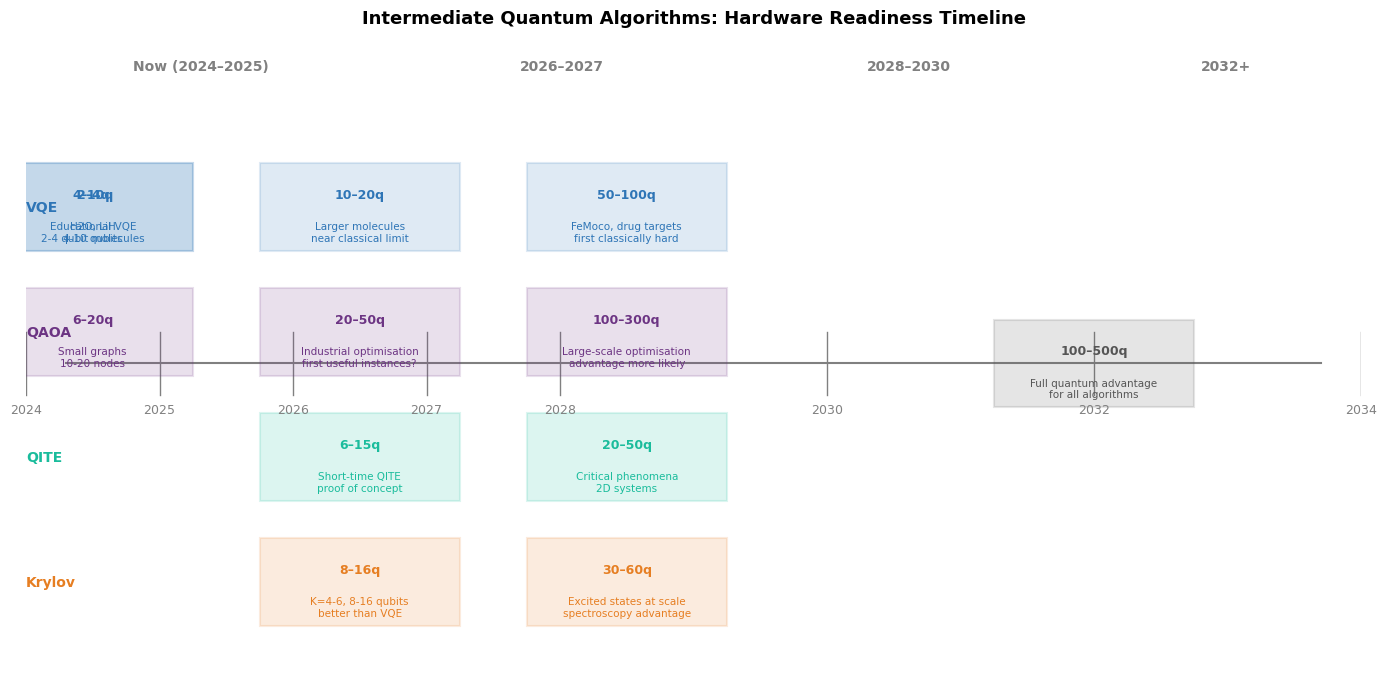

Summary: Qubit requirements for scientifically useful instances

     Algorithm                  Today                    ~2027                    ~2030
----------------------------------------------------------------------------------------
           VQE H2,LiH (2-4q, AaltoQ20) H2O,NH3 (10-20q, IQM150) FeMoco (50-100q, fault-tol)
          QAOA Toy graphs (6-10 nodes) Small industry (20-50 nodes) Large industry (100-300 nodes)
          QITE Proof of concept (4-8q) Phase transitions (10-20q) Critical 2D systems (30-50q)
        Krylov Better than VQE (6-10q)  Excited states (15-25q) Molecular spectroscopy (40-60q)


In [8]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

# Timeline data
# (year, label, algorithm, qubit_range, color, notes)
milestones = [
    # 2024-2025 NOW
    (2024.5, 'AaltoQ20 (IQM)\n20 qubits, ~1ms',     'VQE',    2, 4,  QUANTUM_COLOR,   'Educational VQE\n2-4 qubit molecules'),
    (2024.5, 'IQM Radiance\n54 qubits',              'VQE',    4, 10, QUANTUM_COLOR,   'H2O, LiH\n4-10 qubits'),
    (2024.5, 'IBM Heron / Google Willow\n100-127 qubits','QAOA',6,20, PURPLE_COLOR,   'Small graphs\n10-20 nodes'),
    # 2026-2027
    (2026.5, 'IQM 150-qubit\n(VTT, 2026)',           'VQE',   10, 20, QUANTUM_COLOR,   'Larger molecules\nnear classical limit'),
    (2026.5, 'IBM 1000-qubit class',                 'QAOA',  20, 50, PURPLE_COLOR,   'Industrial optimisation\nfirst useful instances?'),
    (2026.5, 'IQM 300-qubit\n(planned ~2027)',       'QITE',   6, 15, ACCENT_COLOR,   'Short-time QITE\nproof of concept'),
    (2026.5, 'Any 100+ qubit machine',               'Krylov', 8, 16, WARN_COLOR,     'K=4-6, 8-16 qubits\nbetter than VQE'),
    # 2028-2030
    (2028.5, 'Early fault-tolerant\n~1000 logical qubits','VQE',50,100,QUANTUM_COLOR, 'FeMoco, drug targets\nfirst classically hard'),
    (2028.5, 'Fault-tolerant 500+ logical','QAOA',  100,300, PURPLE_COLOR,   'Large-scale optimisation\nadvantage more likely'),
    (2028.5, 'Fault-tolerant 200+ logical','QITE',  20, 50,  ACCENT_COLOR,   'Critical phenomena\n2D systems'),
    (2028.5, 'Fault-tolerant 200+ logical','Krylov',30, 60,  WARN_COLOR,     'Excited states at scale\nspectroscopy advantage'),
    # 2032+
    (2032,   'Full fault-tolerant\n10M+ physical qubits','ALL',100,500,'#555',     'Full quantum advantage\nfor all algorithms'),
]

algo_colors = {'VQE': QUANTUM_COLOR, 'QAOA': PURPLE_COLOR, 'QITE': ACCENT_COLOR, 'Krylov': WARN_COLOR, 'ALL': '#555'}
algo_y = {'VQE': 0.75, 'QAOA': 0.55, 'QITE': 0.35, 'Krylov': 0.15, 'ALL': 0.5}

# Draw timeline axis
years = np.linspace(2024, 2034, 100)
ax.axhline(0.5, xmin=0.03, xmax=0.97, color='gray', lw=1.5, zorder=0)
for yr in [2024, 2025, 2026, 2027, 2028, 2030, 2032, 2034]:
    xpos = (yr - 2024) / (2034 - 2024)
    ax.axvline(xpos, ymin=0.45, ymax=0.55, color='gray', lw=1, zorder=0)
    ax.text(xpos, 0.42, str(yr), ha='center', fontsize=9, color='gray')

# Algorithm legend
for algo, color in algo_colors.items():
    if algo != 'ALL':
        y = algo_y[algo]
        ax.text(0.0, y, algo, fontsize=10, fontweight='bold', color=color,
                ha='left', va='center')

# Draw milestone boxes
placed = []
for (year, hw_label, algo, q_min, q_max, color, notes) in milestones:
    xpos = (year - 2024) / (2034 - 2024)
    if algo == 'ALL':
        ypos = 0.5
    else:
        ypos = algo_y[algo]
    # Box
    bw, bh = 0.15, 0.14
    ax.add_patch(plt.Rectangle((xpos - bw/2, ypos - bh/2), bw, bh,
                                facecolor=color, alpha=0.15,
                                edgecolor=color, lw=1.5,
                                transform=ax.transAxes, zorder=2))
    ax.text(xpos, ypos + 0.02, f'{q_min}–{q_max}q', ha='center', va='center',
            fontsize=9, fontweight='bold', color=color,
            transform=ax.transAxes, zorder=3)
    ax.text(xpos, ypos - 0.04, notes, ha='center', va='center',
            fontsize=7.5, color=color, transform=ax.transAxes, zorder=3)

# Now labels
ax.text(0.08, 0.97, 'Now (2024–2025)', fontsize=10, fontweight='bold',
        color='gray', transform=ax.transAxes)
ax.text(0.37, 0.97, '2026–2027', fontsize=10, fontweight='bold',
        color='gray', transform=ax.transAxes)
ax.text(0.63, 0.97, '2028–2030', fontsize=10, fontweight='bold',
        color='gray', transform=ax.transAxes)
ax.text(0.88, 0.97, '2032+', fontsize=10, fontweight='bold',
        color='gray', transform=ax.transAxes)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title('Intermediate Quantum Algorithms: Hardware Readiness Timeline',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Summary table
print('Summary: Qubit requirements for scientifically useful instances')
print()
print(f'{"Algorithm":>14} {"Today":>22} {"~2027":>24} {"~2030":>24}')
print('-'*88)
rows = [
    ('VQE',    'H2,LiH (2-4q, AaltoQ20)',  'H2O,NH3 (10-20q, IQM150)',      'FeMoco (50-100q, fault-tol)'),
    ('QAOA',   'Toy graphs (6-10 nodes)',   'Small industry (20-50 nodes)',   'Large industry (100-300 nodes)'),
    ('QITE',   'Proof of concept (4-8q)',   'Phase transitions (10-20q)',     'Critical 2D systems (30-50q)'),
    ('Krylov', 'Better than VQE (6-10q)',   'Excited states (15-25q)',        'Molecular spectroscopy (40-60q)'),
]
for row in rows:
    print(f'{row[0]:>14} {row[1]:>22} {row[2]:>24} {row[3]:>24}')

---
# Grand Summary

## The intermediate algorithm landscape

| Algorithm | Quantum resource | No ansatz | Excited states | NISQ today | Advantage proven | Timeline |
|-----------|-----------------|-----------|---------------|-----------|-----------------|----------|
| VQE | Entanglement + variational | No | No | Yes (small) | No | ~2027–2030 |
| QAOA | Entanglement + interference | Partial | No | Yes | No | ~2028–2032 |
| QITE | Non-unitary dynamics | Yes | No | Partial | No | ~2028–2032 |
| Quantum Krylov | Entanglement + projection | Yes | **Yes** | Partial | No | ~2027–2030 |

## The honest picture

All four algorithms are **promising but unproven** at the scales where quantum advantage would be meaningful. This is not a failure — it is exactly where the field is. The simple algorithms (Grover, Deutsch-Jozsa) have proven advantages on toy problems. The intermediate algorithms are the bridge to practical advantage.

The most important near-term milestones:
- **VQE:** find one molecule where quantum gives more accurate energies than classical methods at the same computational cost
- **QAOA:** find one optimisation instance where quantum beats Goemans-Williamson or commercial solvers
- **QITE / Krylov:** demonstrate excited state energies on a system too large for DMRG or CASSCF

## Connecting thread

All four algorithms share the same deep structure:

```
Quantum computer:   prepare and measure quantum states that are
                    classically hard to represent (high entanglement)

Classical computer: extract numbers from those states and
                    do the optimisation / linear algebra

The advantage comes when: the quantum state is both
  (a) classically hard to simulate (lots of entanglement)
  (b) efficiently preparable on quantum hardware (shallow circuit)

The challenge: these two conditions are hard to satisfy simultaneously
```

Finding the problems and system sizes where both conditions hold simultaneously — that is the central open research question in NISQ computing, and the work being done on machines like AaltoQ20 right now.

---
*This notebook simulated all algorithms on classical hardware (Qiskit Aer). Maximum system size: 8 qubits (Hilbert space $2^8 = 256$). Real machines allow the same circuits on larger systems — the algorithms scale, even if the classical simulation does not.*